# Support Vector Machines (SVM) - Complete Tutorial

## Overview

Support Vector Machines (SVMs) are powerful and versatile machine learning models capable of performing:
- **Linear or nonlinear classification**
- **Regression**
- **Outlier detection**

SVMs are particularly well-suited for classification of complex small- or medium-sized datasets.

The key idea behind SVMs is **large margin classification** - they don't just separate classes, but stay as far away from the closest training instances as possible, fitting the widest possible "street" between classes.

## Setup: Import Required Libraries

Let's start by importing all the libraries we'll need for this tutorial.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Scikit-learn imports
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC, LinearSVR, SVR
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# For better visualization
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 1: Linear SVM Classification

### 1.1 Large Margin Classification

The fundamental concept behind SVMs is **large margin classification**. An SVM classifier:
- Separates classes
- Stays as far away from the closest training instances as possible
- Fits the widest possible "street" between classes

**Key Concepts:**
- The decision boundary is fully determined by instances on the edge of the street
- These instances are called **support vectors**
- Adding more training instances "off the street" doesn't affect the decision boundary

### 1.2 Loading and Preparing the Iris Dataset

We'll use the Iris dataset to demonstrate linear SVM classification. We'll focus on classifying Iris Virginica vs. not Virginica based on petal length and width.

Dataset shape: (150, 2)
Number of Iris Virginica samples: 50.0
Number of other samples: 100


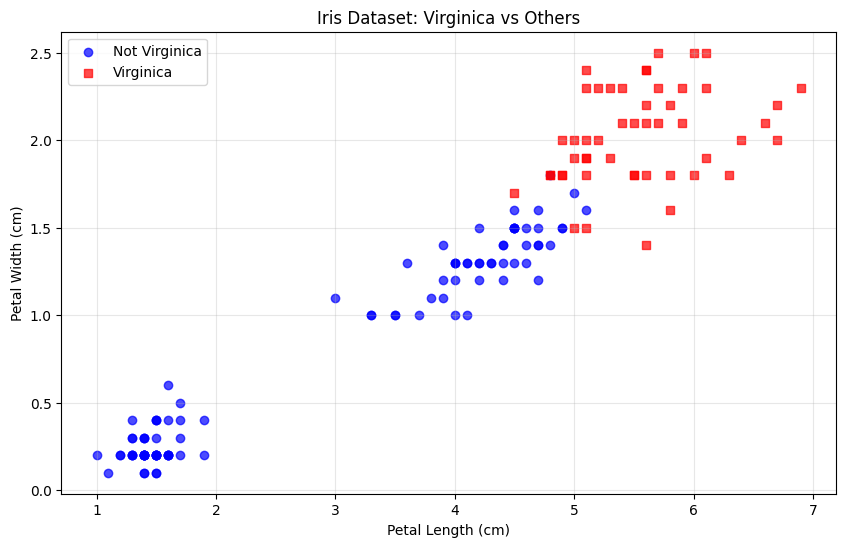

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length (cm), petal width (cm)
y = (iris["target"] == 2).astype(np.float64)  # 1 if Iris virginica, else 0

print(f"Dataset shape: {X.shape}")
print(f"Number of Iris Virginica samples: {y.sum()}")
print(f"Number of other samples: {(y == 0).sum()}")

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', label='Not Virginica', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', label='Virginica', alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset: Virginica vs Others')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 Feature Scaling - Critical for SVMs!

⚠️ **SVMs are sensitive to feature scales.** Always scale your features (e.g., using `StandardScaler`) before training an SVM model.

Let's see why by visualizing the data before and after scaling.

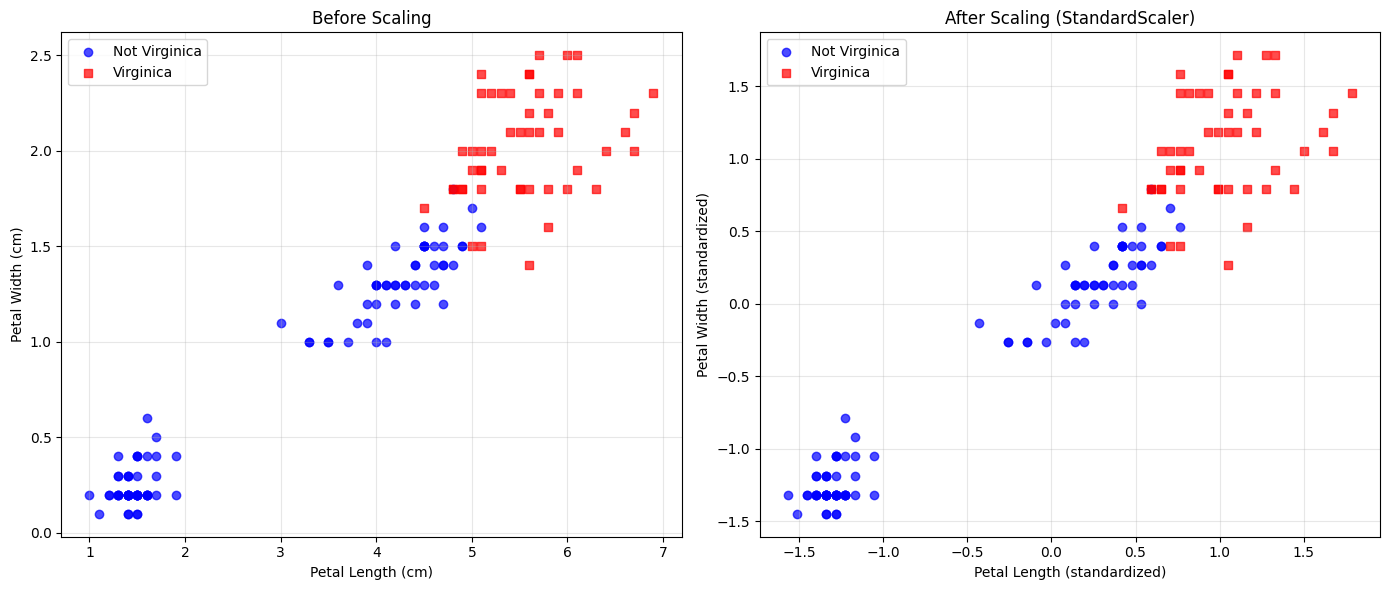

Original data - Mean: [3.758      1.19933333]
Original data - Std: [1.75940407 0.75969263]

Scaled data - Mean: [-4.26325641e-16 -4.73695157e-16]
Scaled data - Std: [1. 1.]


In [3]:
# Create a scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before scaling
axes[0].scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', label='Not Virginica', alpha=0.7)
axes[0].scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', label='Virginica', alpha=0.7)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Before Scaling')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After scaling
axes[1].scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='blue', marker='o', label='Not Virginica', alpha=0.7)
axes[1].scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='red', marker='s', label='Virginica', alpha=0.7)
axes[1].set_xlabel('Petal Length (standardized)')
axes[1].set_ylabel('Petal Width (standardized)')
axes[1].set_title('After Scaling (StandardScaler)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Original data - Mean:", X.mean(axis=0))
print("Original data - Std:", X.std(axis=0))
print("\nScaled data - Mean:", X_scaled.mean(axis=0))
print("Scaled data - Std:", X_scaled.std(axis=0))

### 1.4 Training a Linear SVM Classifier

Now let's train our first SVM classifier using `LinearSVC`. We'll use a **Pipeline** to combine scaling and classification in one step.

**Soft Margin Classification:**
- Balances between keeping the street as large as possible and limiting margin violations
- Controlled by the **C hyperparameter**:
  - **Low C**: More margin violations, larger margin (may generalize better)
  - **High C**: Fewer margin violations, smaller margin
  - If overfitting: reduce C

In [4]:
# Create and train the SVM classifier
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)),
])

svm_clf.fit(X, y)

print("Model trained successfully!")
print(f"Training accuracy: {svm_clf.score(X, y):.4f}")

Model trained successfully!
Training accuracy: 0.9600


### 1.5 Making Predictions

Let's test our trained model with some predictions.

In [5]:
# Make predictions on sample data
sample_data = np.array([
    [5.5, 1.7],  # Likely Virginica
    [3.0, 0.5],  # Likely not Virginica
    [4.5, 1.5],  # Medium characteristics
])

predictions = svm_clf.predict(sample_data)

print("Sample predictions:")
for i, (features, pred) in enumerate(zip(sample_data, predictions)):
    class_name = "Virginica" if pred == 1 else "Not Virginica"
    print(f"  Sample {i+1}: Petal Length={features[0]:.1f}, Petal Width={features[1]:.1f} -> {class_name}")

print("\n⚠️ Important Note: Unlike Logistic Regression, SVM classifiers do not output probabilities for each class.")

Sample predictions:
  Sample 1: Petal Length=5.5, Petal Width=1.7 -> Virginica
  Sample 2: Petal Length=3.0, Petal Width=0.5 -> Not Virginica
  Sample 3: Petal Length=4.5, Petal Width=1.5 -> Not Virginica

⚠️ Important Note: Unlike Logistic Regression, SVM classifiers do not output probabilities for each class.


### 1.6 Visualizing the Decision Boundary

Let's create a visualization to see the decision boundary and the "street" (margin) that the SVM creates.

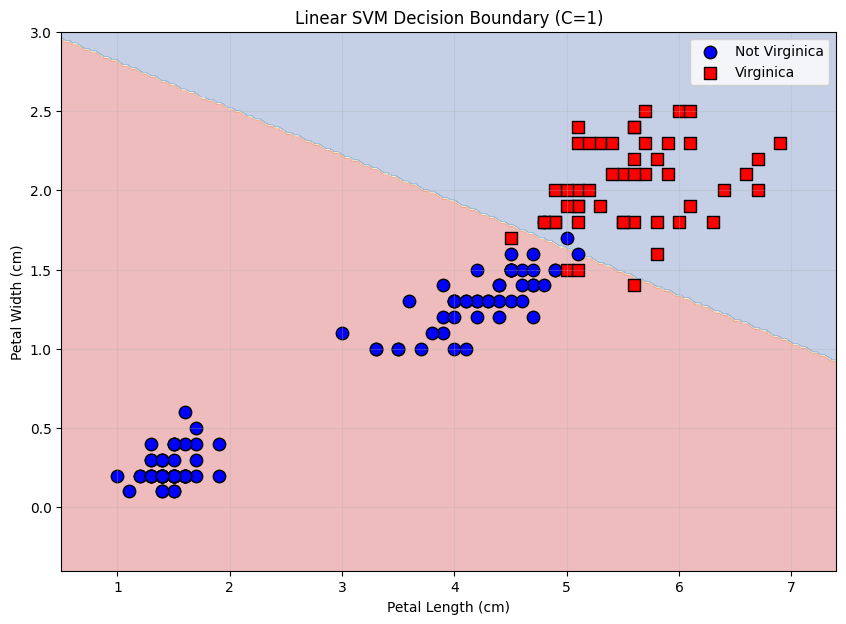

In [6]:
def plot_svm_decision_boundary(clf, X, y, title="SVM Decision Boundary"):
    """Plot decision boundary for SVM classifier"""
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', 
                label='Not Virginica', edgecolors='k', s=80)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', 
                label='Virginica', edgecolors='k', s=80)
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize the decision boundary
plot_svm_decision_boundary(svm_clf, X, y, "Linear SVM Decision Boundary (C=1)")

### 1.7 Effect of C Hyperparameter

Let's compare different values of C to understand its effect on the decision boundary.

C=  0.01: Training accuracy = 0.7600
C=  1.00: Training accuracy = 0.9600
C=100.00: Training accuracy = 0.9600


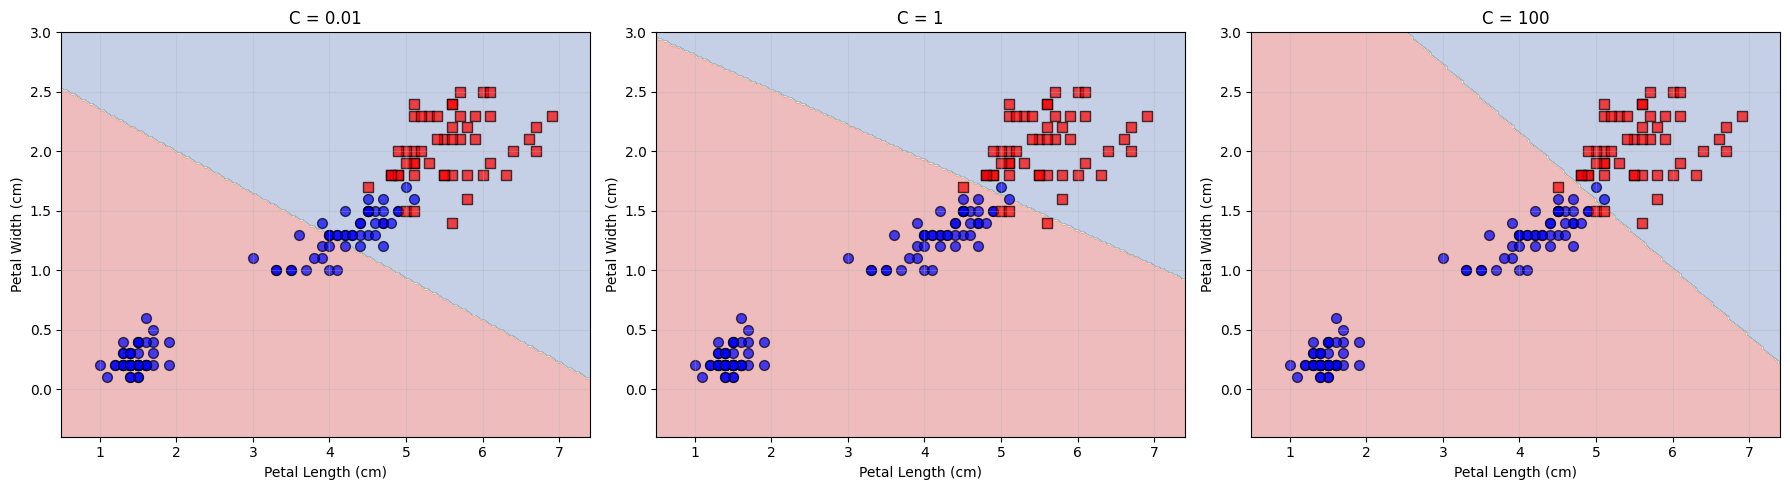


💡 Observation:
  - Low C (0.01): Wider margin, more violations allowed (regularized)
  - High C (100): Narrower margin, fewer violations (may overfit)


In [7]:
# Train models with different C values
C_values = [0.01, 1, 100]
models = {}

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=C, loss="hinge", random_state=42)),
    ])
    model.fit(X, y)
    models[C] = model
    print(f"C={C:6.2f}: Training accuracy = {model.score(X, y):.4f}")

# Visualize all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, C in enumerate(C_values):
    clf = models[C]
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    axes[idx].scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', 
                     edgecolors='k', s=50, alpha=0.7)
    axes[idx].scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', 
                     edgecolors='k', s=50, alpha=0.7)
    axes[idx].set_xlabel('Petal Length (cm)')
    axes[idx].set_ylabel('Petal Width (cm)')
    axes[idx].set_title(f'C = {C}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observation:")
print("  - Low C (0.01): Wider margin, more violations allowed (regularized)")
print("  - High C (100): Narrower margin, fewer violations (may overfit)")

### 1.8 Alternative SVM Implementations

There are different ways to train linear SVMs in scikit-learn:

1. **LinearSVC**: Fast implementation for linear kernels
2. **SVC with linear kernel**: More flexible but slower
3. **SGDClassifier**: Uses Stochastic Gradient Descent, good for very large datasets

Let's compare them!

In [8]:
# Train all three types
import time

# 1. LinearSVC
start = time.time()
linear_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(C=1, loss="hinge", random_state=42)),
])
linear_svc.fit(X, y)
time_linear_svc = time.time() - start

# 2. SVC with linear kernel
start = time.time()
svc_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1, random_state=42)),
])
svc_linear.fit(X, y)
time_svc = time.time() - start

# 3. SGDClassifier
start = time.time()
m = len(X)
sgd_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(loss="hinge", alpha=1/(m*1), random_state=42, max_iter=1000)),
])
sgd_clf.fit(X, y)
time_sgd = time.time() - start

# Compare results
print("Comparison of SVM Implementations:\n")
print(f"{'Method':<20} {'Accuracy':<12} {'Training Time':<15}")
print("-" * 50)
print(f"{'LinearSVC':<20} {linear_svc.score(X, y):<12.4f} {time_linear_svc:<15.6f} sec")
print(f"{'SVC(linear)':<20} {svc_linear.score(X, y):<12.4f} {time_svc:<15.6f} sec")
print(f"{'SGDClassifier':<20} {sgd_clf.score(X, y):<12.4f} {time_sgd:<15.6f} sec")

print("\n💡 Key Takeaway:")
print("  - LinearSVC is fastest for linear problems")
print("  - SGDClassifier is useful for online learning or huge datasets")
print("  - SVC(kernel='linear') is slower but more flexible")

Comparison of SVM Implementations:

Method               Accuracy     Training Time  
--------------------------------------------------
LinearSVC            0.9600       0.000000        sec
SVC(linear)          0.9533       0.008653        sec
SGDClassifier        0.9600       0.000000        sec

💡 Key Takeaway:
  - LinearSVC is fastest for linear problems
  - SGDClassifier is useful for online learning or huge datasets
  - SVC(kernel='linear') is slower but more flexible


## Part 2: Nonlinear SVM Classification

### 2.1 The Problem with Linear Classifiers

Many real-world datasets are not linearly separable. Let's create a dataset that demonstrates this challenge: the **moons dataset**.

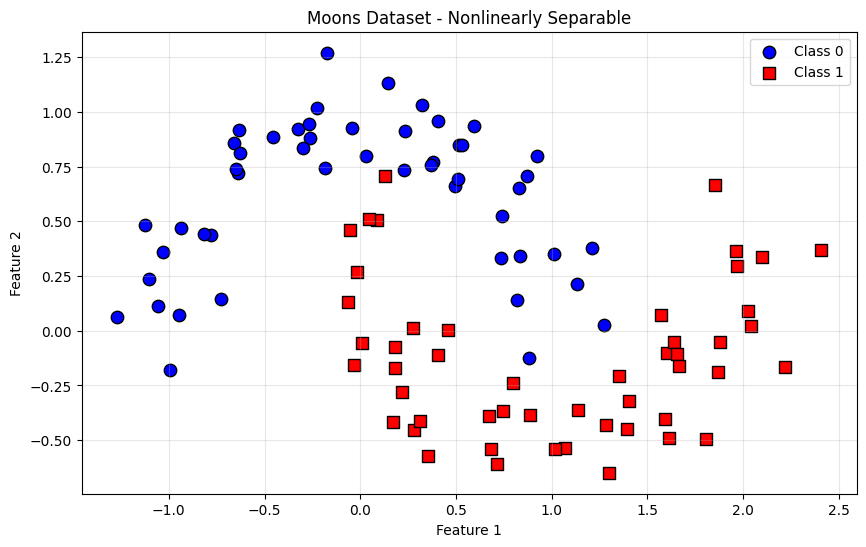

This dataset cannot be separated by a straight line!


In [9]:
# Create a nonlinear dataset (moons)
X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=42)

# Visualize the moons dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], 
            c='blue', marker='o', label='Class 0', edgecolors='k', s=80)
plt.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], 
            c='red', marker='s', label='Class 1', edgecolors='k', s=80)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moons Dataset - Nonlinearly Separable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("This dataset cannot be separated by a straight line!")

### 2.2 Approach 1: Adding Polynomial Features

One approach to handle nonlinear datasets is to add polynomial features to make them linearly separable in a higher-dimensional space.

Training accuracy with polynomial features: 0.9700


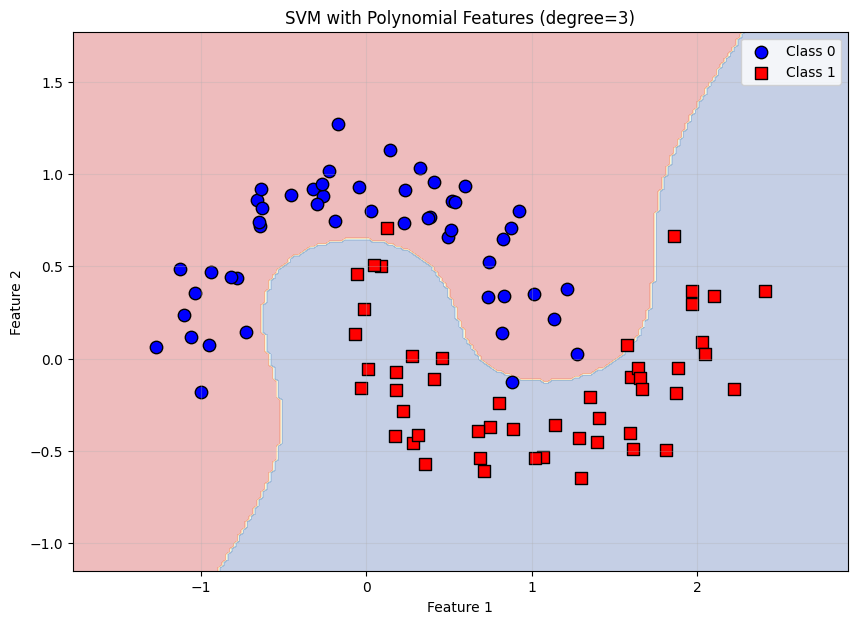


⚠️ Problem: High-degree polynomials create many features, making training slow!


In [10]:
# Train SVM with polynomial features
polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", random_state=42, max_iter=10000))
])

polynomial_svm_clf.fit(X_moons, y_moons)

print(f"Training accuracy with polynomial features: {polynomial_svm_clf.score(X_moons, y_moons):.4f}")

# Visualize decision boundary
def plot_decision_boundary(clf, X, y, title="Decision Boundary"):
    """Plot decision boundary for any classifier"""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', 
                label='Class 0', edgecolors='k', s=80)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', 
                label='Class 1', edgecolors='k', s=80)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(polynomial_svm_clf, X_moons, y_moons, 
                       "SVM with Polynomial Features (degree=3)")

print("\n⚠️ Problem: High-degree polynomials create many features, making training slow!")

### 2.3 Approach 2: Polynomial Kernel (The Kernel Trick!)

The **kernel trick** makes it possible to get the same result as adding many polynomial features without actually adding them, avoiding the combinatorial explosion of features.

**Key Insight:** Instead of transforming data to higher dimensions and computing dot products, we use a kernel function that computes the result directly!

**Polynomial Kernel Formula:**
$$K(\mathbf{a}, \mathbf{b}) = (\gamma\mathbf{a}^\top\mathbf{b} + r)^d$$

where:
- $d$ = degree
- $\gamma$ (gamma) = kernel coefficient
- $r$ = coef0 (independent term)

Training accuracy with polynomial kernel: 0.9800


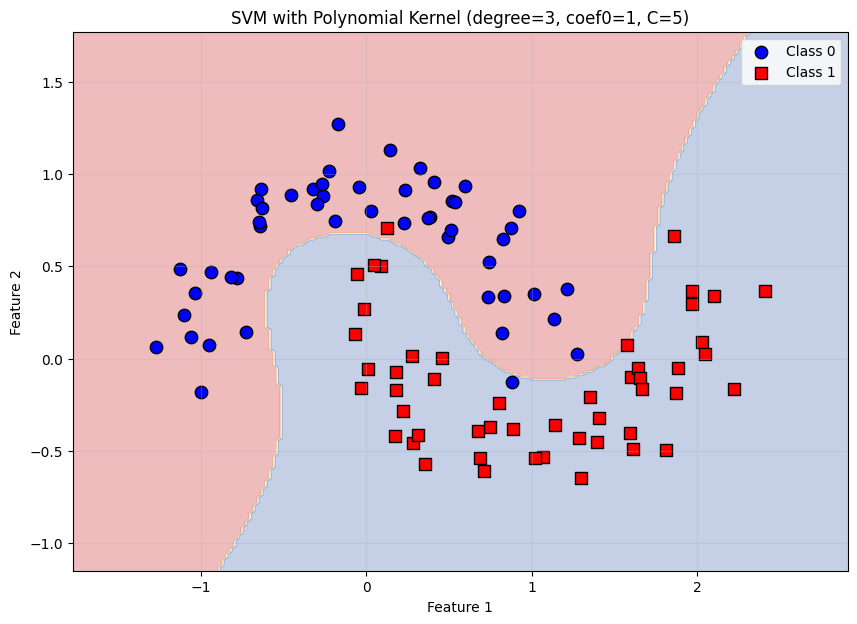


✅ Advantage: Much faster! Gets same results without explicitly creating polynomial features.


In [11]:
# Train SVM with polynomial kernel
poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5, random_state=42))
])

poly_kernel_svm_clf.fit(X_moons, y_moons)

print(f"Training accuracy with polynomial kernel: {poly_kernel_svm_clf.score(X_moons, y_moons):.4f}")

# Visualize
plot_decision_boundary(poly_kernel_svm_clf, X_moons, y_moons, 
                       "SVM with Polynomial Kernel (degree=3, coef0=1, C=5)")

print("\n✅ Advantage: Much faster! Gets same results without explicitly creating polynomial features.")

### 2.4 Tuning Polynomial Kernel Hyperparameters

Let's explore how different hyperparameters affect the polynomial kernel:
- **degree**: Polynomial degree (higher = more complex)
- **coef0**: Influences high-degree vs. low-degree polynomials
- **C**: Regularization (lower = more regularization)

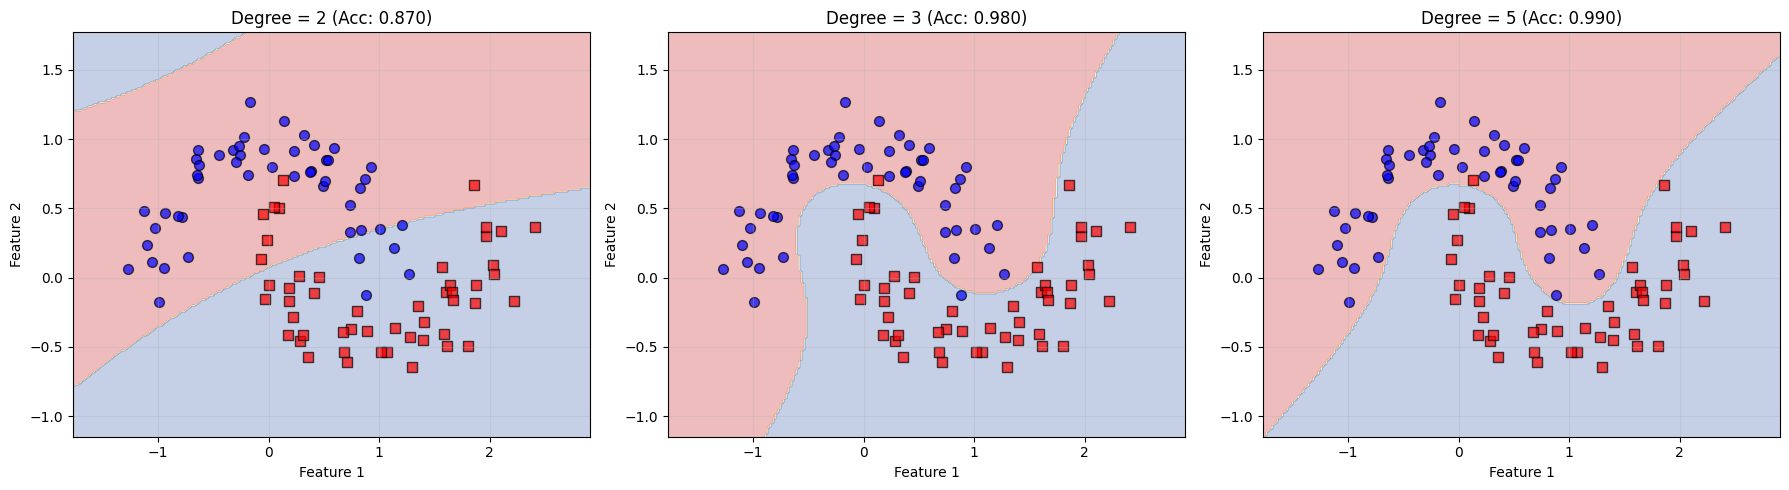

💡 Observation:
  - Low degree: May underfit (too simple)
  - High degree: May overfit (too complex, wiggly boundaries)


In [12]:
# Compare different polynomial degrees
degrees = [2, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, degree in enumerate(degrees):
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=degree, coef0=1, C=5, random_state=42))
    ])
    clf.fit(X_moons, y_moons)
    
    # Create mesh
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    axes[idx].scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], 
                     c='blue', marker='o', edgecolors='k', s=50, alpha=0.7)
    axes[idx].scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], 
                     c='red', marker='s', edgecolors='k', s=50, alpha=0.7)
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].set_title(f'Degree = {degree} (Acc: {clf.score(X_moons, y_moons):.3f})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Observation:")
print("  - Low degree: May underfit (too simple)")
print("  - High degree: May overfit (too complex, wiggly boundaries)")

### 2.5 Gaussian RBF Kernel - The Most Popular!

The **Gaussian Radial Basis Function (RBF)** kernel is one of the most commonly used kernels. It uses similarity features based on distance to landmarks.

**Gaussian RBF Formula:**
$$K(\mathbf{a}, \mathbf{b}) = \exp(-\gamma \|\mathbf{a} - \mathbf{b}\|^2)$$

where $\gamma$ (gamma) is a hyperparameter that controls the influence range:
- **High gamma**: Narrow influence, more complex boundary (may overfit)
- **Low gamma**: Wide influence, smoother boundary (may underfit)

The RBF kernel is particularly powerful because it can map to **infinite-dimensional space**!

Training accuracy with RBF kernel: 0.9700


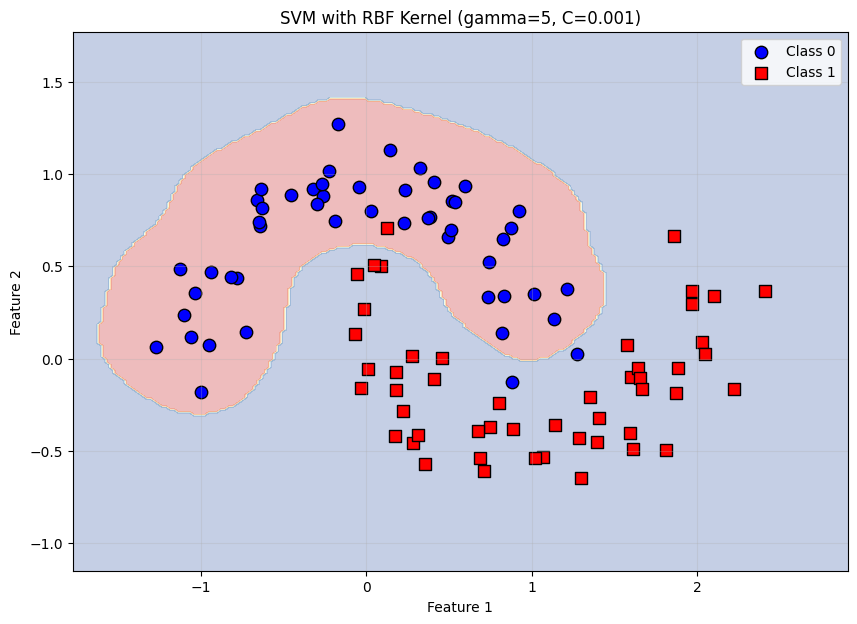


✅ RBF kernel is very versatile and works well in most cases!


In [13]:
# Train SVM with RBF kernel
rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001, random_state=42))
])

rbf_kernel_svm_clf.fit(X_moons, y_moons)

print(f"Training accuracy with RBF kernel: {rbf_kernel_svm_clf.score(X_moons, y_moons):.4f}")

# Visualize
plot_decision_boundary(rbf_kernel_svm_clf, X_moons, y_moons, 
                       "SVM with RBF Kernel (gamma=5, C=0.001)")

print("\n✅ RBF kernel is very versatile and works well in most cases!")

### 2.6 Effect of Gamma and C in RBF Kernel

Let's explore how gamma and C affect the RBF kernel's decision boundary.

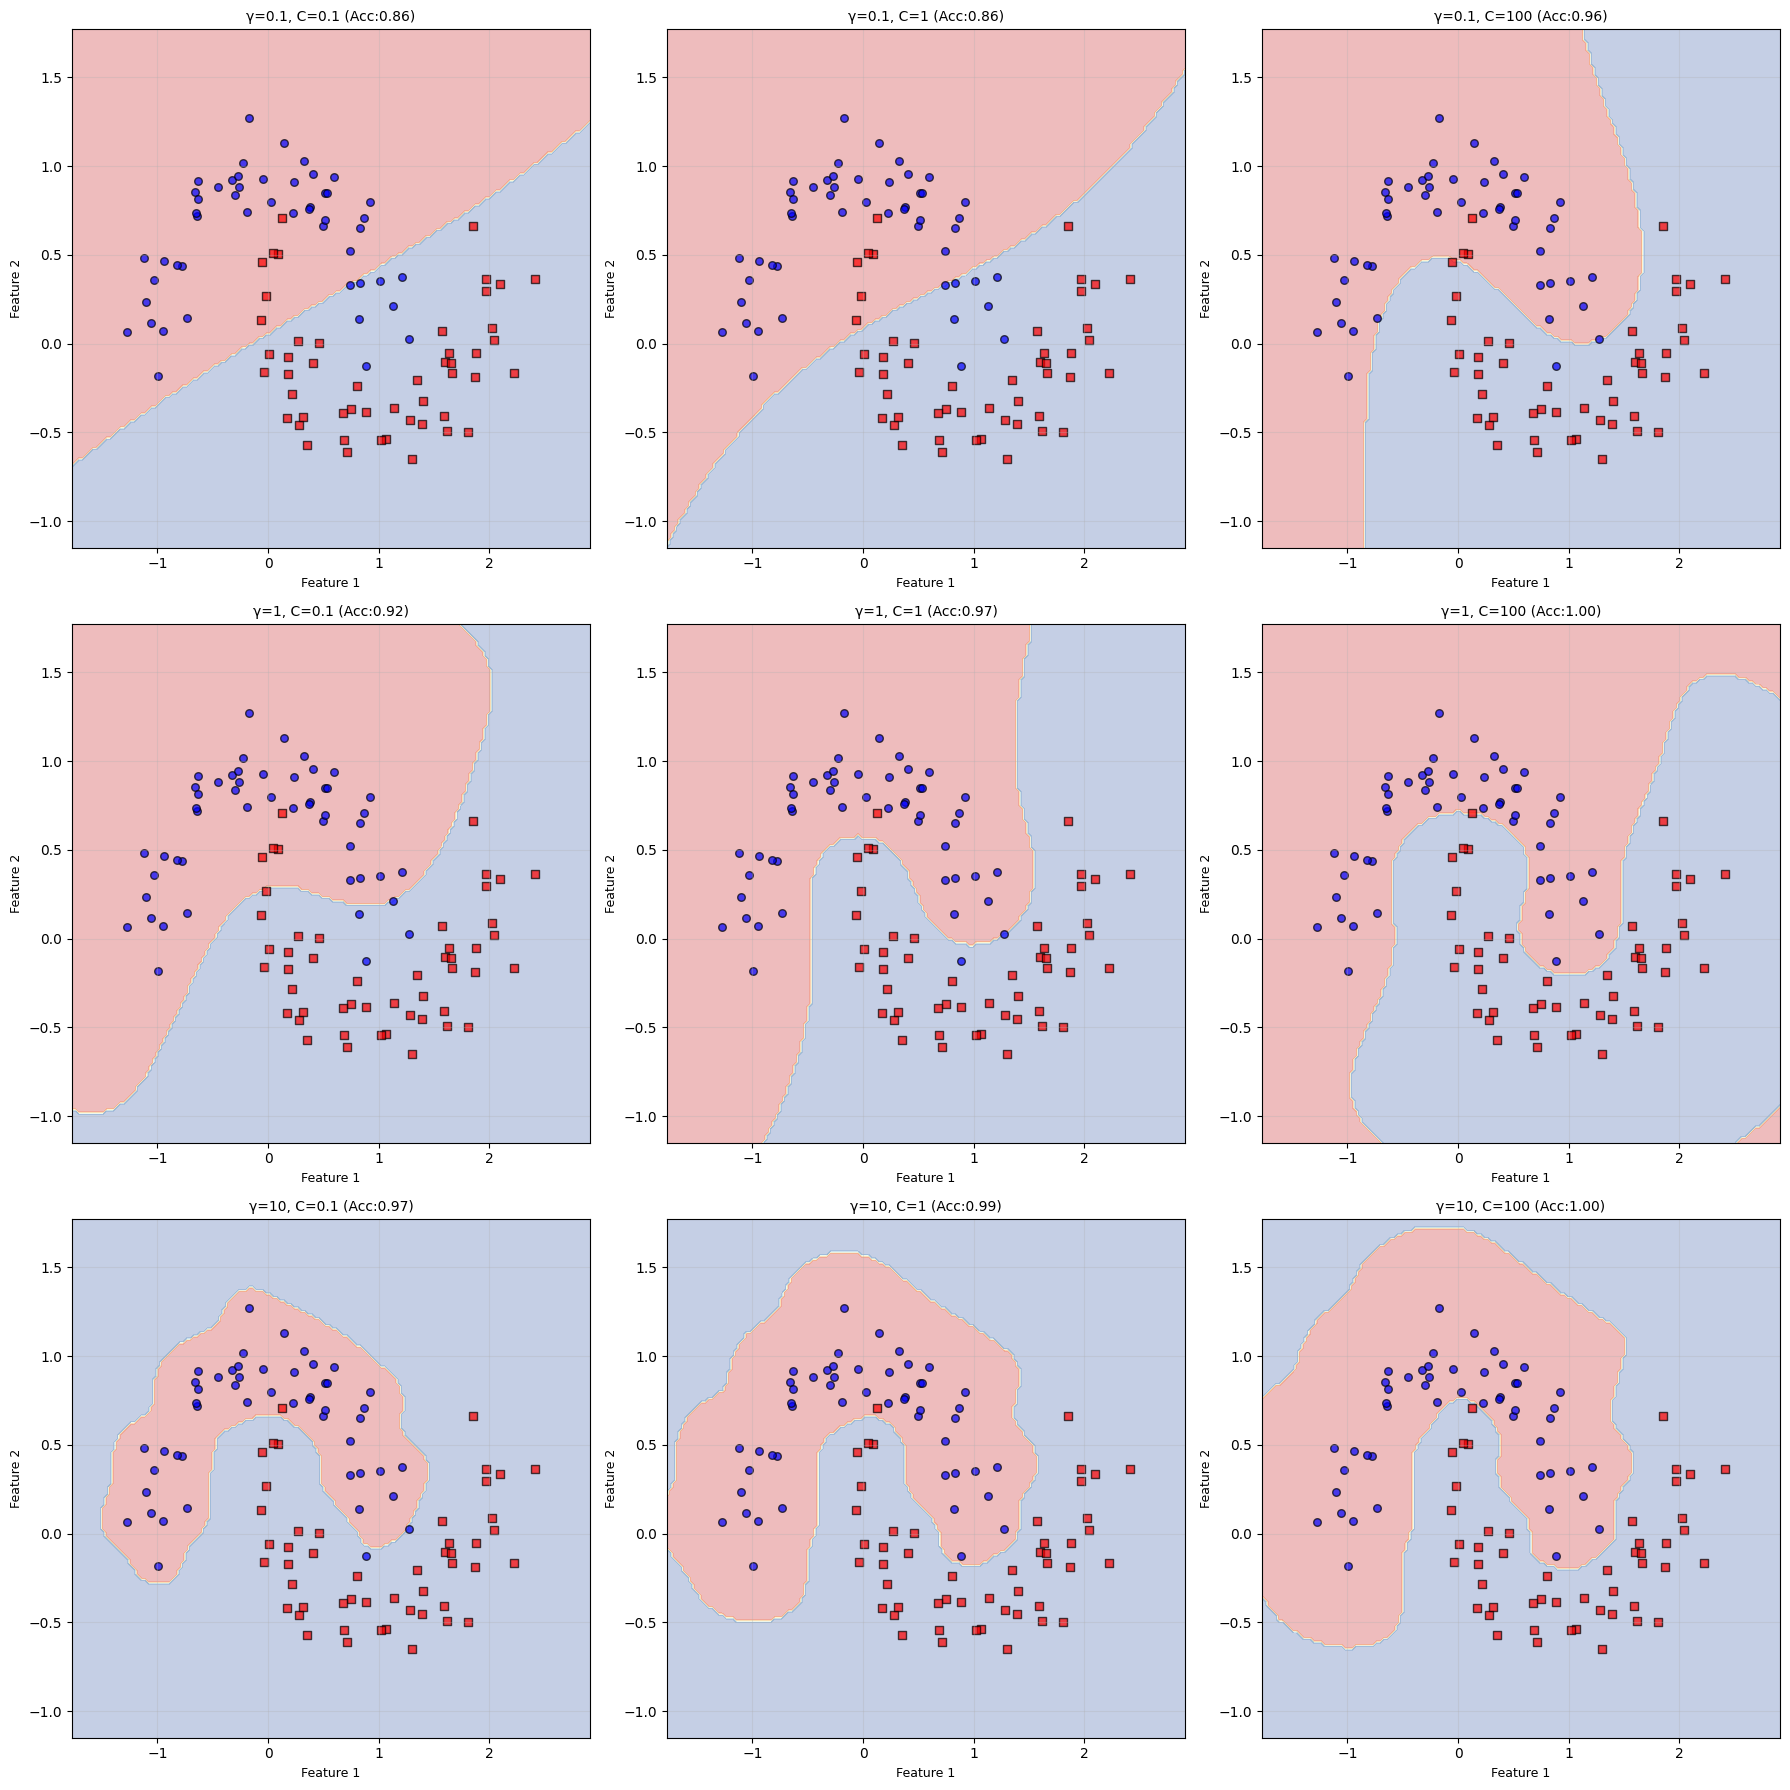


💡 Key Observations:
  - Increasing gamma → More complex, wiggly boundaries (risk of overfitting)
  - Decreasing gamma → Smoother boundaries (risk of underfitting)
  - Increasing C → Fewer margin violations, tighter fit
  - Decreasing C → More margin violations, more regularization

🎯 Best practice: Use cross-validation to find optimal gamma and C!


In [14]:
# Create a grid of gamma and C values
gamma_values = [0.1, 1, 10]
C_values = [0.1, 1, 100]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm_clf", SVC(kernel="rbf", gamma=gamma, C=C, random_state=42))
        ])
        clf.fit(X_moons, y_moons)
        
        # Create mesh
        x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
        y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150),
                             np.linspace(y_min, y_max, 150))
        
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Plot
        axes[i, j].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
        axes[i, j].scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], 
                          c='blue', marker='o', edgecolors='k', s=30, alpha=0.7)
        axes[i, j].scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], 
                          c='red', marker='s', edgecolors='k', s=30, alpha=0.7)
        axes[i, j].set_title(f'γ={gamma}, C={C} (Acc:{clf.score(X_moons, y_moons):.2f})', 
                            fontsize=10)
        axes[i, j].set_xlabel('Feature 1', fontsize=9)
        axes[i, j].set_ylabel('Feature 2', fontsize=9)
        axes[i, j].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("  - Increasing gamma → More complex, wiggly boundaries (risk of overfitting)")
print("  - Decreasing gamma → Smoother boundaries (risk of underfitting)")
print("  - Increasing C → Fewer margin violations, tighter fit")
print("  - Decreasing C → More margin violations, more regularization")
print("\n🎯 Best practice: Use cross-validation to find optimal gamma and C!")

## Part 3: SVM Regression

SVMs can also be used for regression! The approach is reversed: instead of fitting the largest street between classes while limiting margin violations, SVM Regression tries to fit as many instances as possible **on the street** while limiting margin violations (instances off the street).

**Key Parameter:** 
- **epsilon (ε)**: Controls the width of the street
- Larger ε: Wider street, more instances fit on it
- Smaller ε: Narrower street, fewer instances fit on it

### 3.1 Linear SVM Regression

Let's start with linear regression using SVMs.

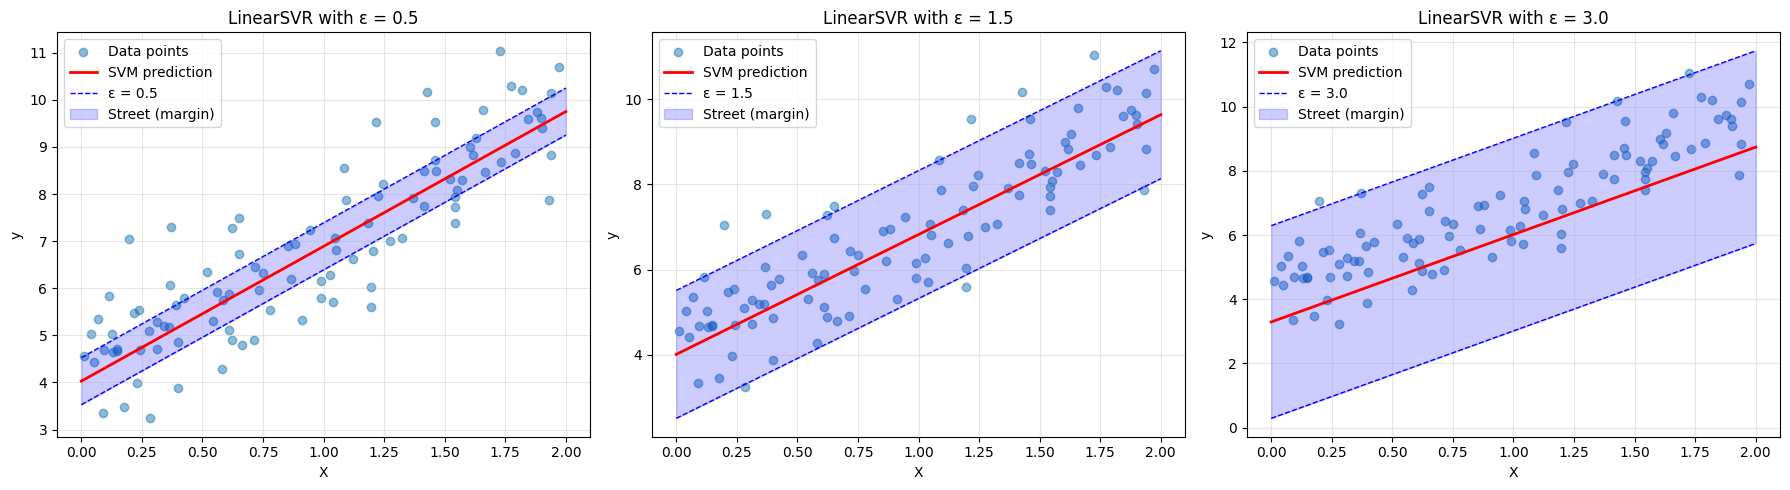

💡 Observation:
  - Small ε: Narrow street, predictions closer to data
  - Large ε: Wide street, more tolerance for errors
  - Points within the street don't affect the model (ε-insensitive)


In [15]:
# Generate synthetic regression data
np.random.seed(42)
X_reg = 2 * np.random.rand(100, 1)
y_reg = 4 + 3 * X_reg + np.random.randn(100, 1)
y_reg = y_reg.ravel()

# Train linear SVM regressor with different epsilon values
epsilon_values = [0.5, 1.5, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, epsilon in enumerate(epsilon_values):
    svm_reg = LinearSVR(epsilon=epsilon, random_state=42)
    svm_reg.fit(X_reg, y_reg)
    
    # Make predictions
    X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
    y_pred = svm_reg.predict(X_plot)
    
    # Plot
    axes[idx].scatter(X_reg, y_reg, alpha=0.5, label='Data points')
    axes[idx].plot(X_plot, y_pred, 'r-', linewidth=2, label='SVM prediction')
    axes[idx].plot(X_plot, y_pred + epsilon, 'b--', linewidth=1, label=f'ε = {epsilon}')
    axes[idx].plot(X_plot, y_pred - epsilon, 'b--', linewidth=1)
    axes[idx].fill_between(X_plot.ravel(), y_pred - epsilon, y_pred + epsilon, 
                          alpha=0.2, color='blue', label='Street (margin)')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'LinearSVR with ε = {epsilon}')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Observation:")
print("  - Small ε: Narrow street, predictions closer to data")
print("  - Large ε: Wide street, more tolerance for errors")
print("  - Points within the street don't affect the model (ε-insensitive)")

### 3.2 Nonlinear SVM Regression

For nonlinear regression tasks, we can use kernelized SVM models, just like in classification!

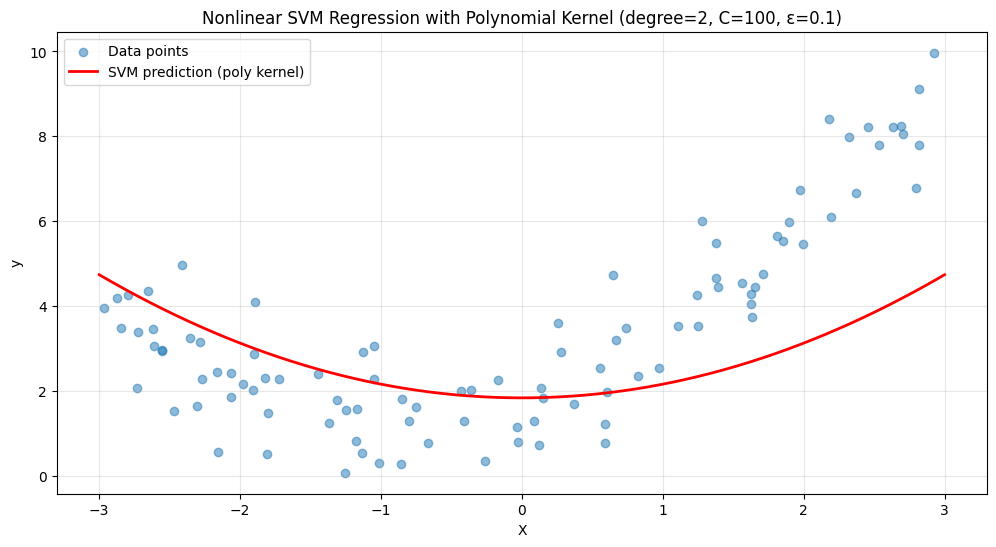

Training score (R²): 0.2369

✅ SVM regression works great for nonlinear patterns using kernels!


In [18]:
# Generate nonlinear data
np.random.seed(42)
X_nonlinear = 6 * np.random.rand(100, 1) - 3
y_nonlinear = 0.5 * X_nonlinear**2 + X_nonlinear + 2 + np.random.randn(100, 1)
y_nonlinear = y_nonlinear.ravel()

# Train polynomial SVM regressor
svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)
svm_poly_reg.fit(X_nonlinear, y_nonlinear)

# Make predictions
X_plot_nonlinear = np.linspace(-3, 3, 200).reshape(-1, 1)
y_pred_poly = svm_poly_reg.predict(X_plot_nonlinear)

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.5, label='Data points')
plt.plot(X_plot_nonlinear, y_pred_poly, 'r-', linewidth=2, label='SVM prediction (poly kernel)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Nonlinear SVM Regression with Polynomial Kernel (degree=2, C=100, ε=0.1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training score (R²): {svm_poly_reg.score(X_nonlinear, y_nonlinear):.4f}")
print("\n✅ SVM regression works great for nonlinear patterns using kernels!")

## Part 4: Computational Complexity

Understanding the computational complexity helps you choose the right SVM implementation for your problem.

### Time Complexity Comparison

| Class | Time Complexity | Best For | Kernel Support |
|-------|----------------|----------|----------------|
| **LinearSVC** | O(m × n) | Large datasets, many features | No |
| **SGDClassifier** | O(m × n) | Huge datasets, online learning | No |
| **SVC** | O(m² × n) to O(m³ × n) | Small/medium datasets, nonlinear | Yes |

where:
- m = number of training instances
- n = number of features

### Practical Guidelines

**Use LinearSVC or SGDClassifier when:**
- You have a large training set (hundreds of thousands of instances)
- The problem is linearly separable
- You need fast training

**Use SVC with kernels when:**
- You have a small to medium training set
- The problem is nonlinear
- You can afford longer training times

Training Time Comparison:

Dataset Size    LinearSVC (sec)      SVC-RBF (sec)       
-------------------------------------------------------
100             0.003078             0.005023            
500             0.003001             0.005129            
1000            0.001997             0.006228            


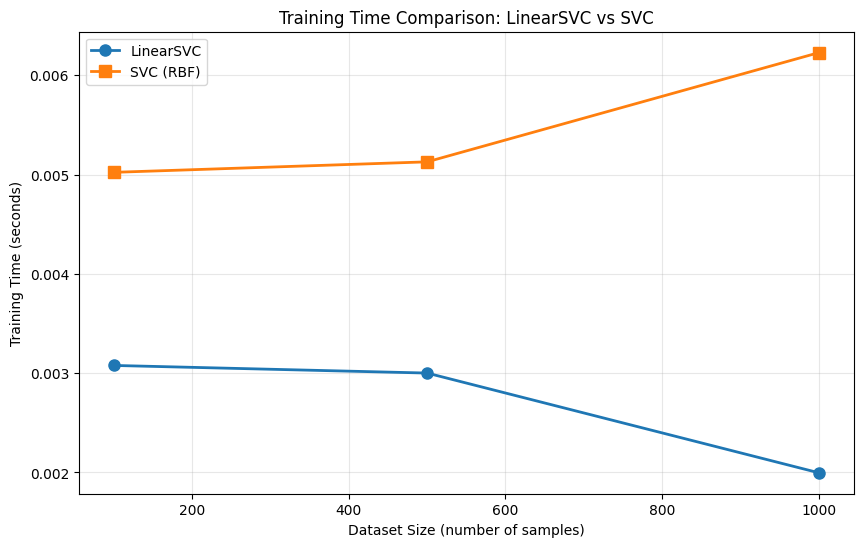


💡 As dataset size grows:
  - LinearSVC scales approximately linearly O(m × n)
  - SVC with kernel scales quadratically to cubically O(m² × n) to O(m³ × n)
  - For large datasets, LinearSVC is much faster!


In [19]:
# Demonstrate computational complexity with timing experiments
import time

# Create datasets of different sizes
sizes = [100, 500, 1000]
linear_times = []
svc_times = []

print("Training Time Comparison:\n")
print(f"{'Dataset Size':<15} {'LinearSVC (sec)':<20} {'SVC-RBF (sec)':<20}")
print("-" * 55)

for size in sizes:
    # Generate data
    X_test, y_test = make_moons(n_samples=size, noise=0.15, random_state=42)
    
    # Time LinearSVC
    start = time.time()
    clf_linear = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", LinearSVC(C=1, loss="hinge", random_state=42, max_iter=1000))
    ])
    clf_linear.fit(X_test, y_test)
    time_linear = time.time() - start
    linear_times.append(time_linear)
    
    # Time SVC with RBF kernel
    start = time.time()
    clf_rbf = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", gamma=1, C=1, random_state=42))
    ])
    clf_rbf.fit(X_test, y_test)
    time_rbf = time.time() - start
    svc_times.append(time_rbf)
    
    print(f"{size:<15} {time_linear:<20.6f} {time_rbf:<20.6f}")

# Visualize timing
plt.figure(figsize=(10, 6))
plt.plot(sizes, linear_times, 'o-', label='LinearSVC', linewidth=2, markersize=8)
plt.plot(sizes, svc_times, 's-', label='SVC (RBF)', linewidth=2, markersize=8)
plt.xlabel('Dataset Size (number of samples)')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison: LinearSVC vs SVC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 As dataset size grows:")
print("  - LinearSVC scales approximately linearly O(m × n)")
print("  - SVC with kernel scales quadratically to cubically O(m² × n) to O(m³ × n)")
print("  - For large datasets, LinearSVC is much faster!")

## Part 5: Under the Hood - How SVMs Work

Let's understand the mathematical foundation of SVMs.

### 5.1 Decision Function

For a linear SVM, the decision function is:

$$\mathbf{w}^\top \mathbf{x} + b = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$$

where:
- **w**: weight vector (feature weights)
- **b**: bias term
- **x**: input feature vector

**Prediction rule:**
- If $\mathbf{w}^\top\mathbf{x} + b \geq 0$ → predict class 1
- If $\mathbf{w}^\top\mathbf{x} + b < 0$ → predict class 0

The decision boundary is where the decision function equals 0.

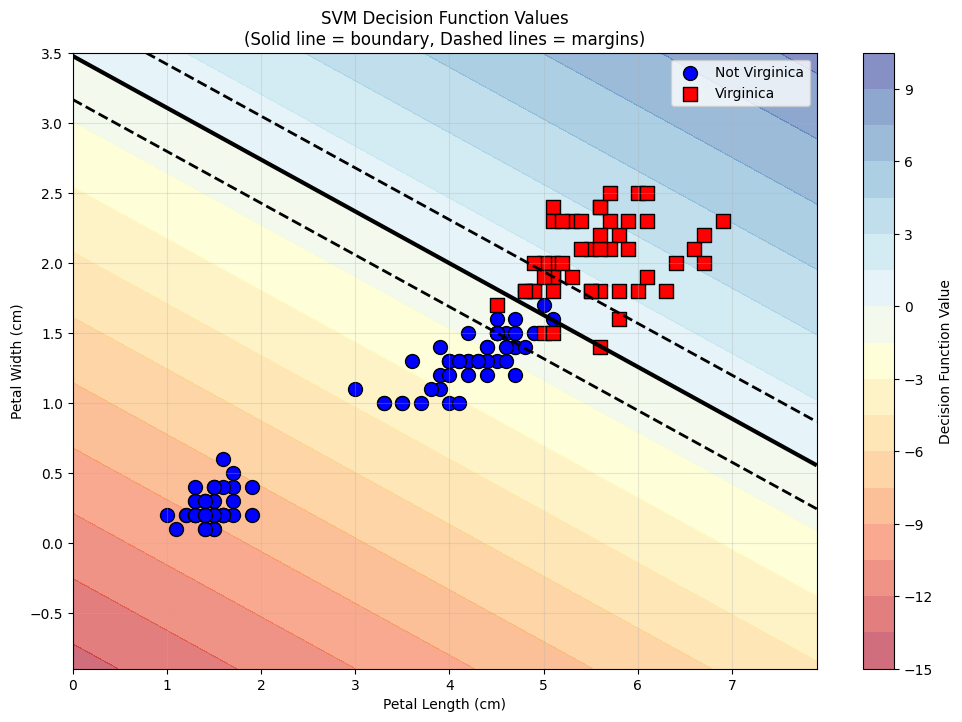

💡 Understanding the visualization:
  - Blue regions: Negative decision function values → Class 0
  - Red regions: Positive decision function values → Class 1
  - Black solid line: Decision boundary (function = 0)
  - Black dashed lines: Margins (function = ±1)
  - Support vectors: Points on or within the margins


In [20]:
# Visualize decision function values
# Train a simple linear SVM
simple_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1, random_state=42))
])

simple_svm.fit(X, y)

# Get decision function values
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Compute decision function for each point
Z = simple_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.colorbar(label='Decision Function Value')

# Plot decision boundary (where decision function = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=3, colors='black', 
            linestyles='solid', label='Decision Boundary')

# Plot margins (where decision function = ±1)
plt.contour(xx, yy, Z, levels=[-1, 1], linewidths=2, colors='black', 
            linestyles='dashed')

# Plot data points
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', 
            label='Not Virginica', edgecolors='k', s=100)
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', 
            label='Virginica', edgecolors='k', s=100)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('SVM Decision Function Values\n(Solid line = boundary, Dashed lines = margins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Understanding the visualization:")
print("  - Blue regions: Negative decision function values → Class 0")
print("  - Red regions: Positive decision function values → Class 1")
print("  - Black solid line: Decision boundary (function = 0)")
print("  - Black dashed lines: Margins (function = ±1)")
print("  - Support vectors: Points on or within the margins")

### 5.2 Training Objective: Hard vs Soft Margin

**Hard Margin Classification:**

Minimize $\frac{1}{2}\mathbf{w}^\top\mathbf{w}$ (maximize margin)

Subject to: $t^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) \geq 1$ for all instances

where $t^{(i)} = -1$ for negative class, $t^{(i)} = 1$ for positive class

**Problem:** Only works if data is perfectly linearly separable

**Soft Margin Classification:**

Introduces **slack variables** $\zeta^{(i)} \geq 0$ to allow margin violations

Minimize: $\frac{1}{2}\mathbf{w}^\top\mathbf{w} + C\sum_{i=1}^m \zeta^{(i)}$

Subject to: $t^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) \geq 1 - \zeta^{(i)}$ and $\zeta^{(i)} \geq 0$

The **C hyperparameter** balances:
- Making $\zeta^{(i)}$ small (fewer violations) ← controlled by C
- Making $\frac{1}{2}\mathbf{w}^\top\mathbf{w}$ small (larger margin)

### 5.3 The Kernel Trick Explained

The kernel trick is one of the most elegant concepts in machine learning!

**Problem:** Transforming data to high dimensions and computing dot products is expensive.

**Solution:** Use a kernel function K(a, b) that computes the dot product of transformed vectors WITHOUT explicitly transforming them!

**Example: 2nd Degree Polynomial**

Original transformation:
$$\phi\left(\begin{bmatrix}x_1\\x_2\end{bmatrix}\right) = \begin{bmatrix}x_1^2\\\sqrt{2}x_1x_2\\x_2^2\end{bmatrix}$$

Computing dot product of transformed vectors:
$$\phi(\mathbf{a})^\top\phi(\mathbf{b}) = a_1^2 b_1^2 + 2a_1b_1a_2b_2 + a_2^2 b_2^2 = (a_1b_1 + a_2b_2)^2 = (\mathbf{a}^\top\mathbf{b})^2$$

**Kernel trick:** Just compute $K(\mathbf{a}, \mathbf{b}) = (\mathbf{a}^\top\mathbf{b})^2$ directly!

### Common Kernels

1. **Linear:** $K(\mathbf{a}, \mathbf{b}) = \mathbf{a}^\top\mathbf{b}$

2. **Polynomial:** $K(\mathbf{a}, \mathbf{b}) = (\gamma\mathbf{a}^\top\mathbf{b} + r)^d$

3. **Gaussian RBF:** $K(\mathbf{a}, \mathbf{b}) = \exp(-\gamma\|\mathbf{a} - \mathbf{b}\|^2)$

4. **Sigmoid:** $K(\mathbf{a}, \mathbf{b}) = \tanh(\gamma\mathbf{a}^\top\mathbf{b} + r)$

**Mercer's Theorem:** If a function K respects certain conditions (continuous, symmetric, etc.), then there exists a transformation φ such that K(a,b) = φ(a)⊺φ(b).

**Amazing fact:** The Gaussian RBF kernel maps to **infinite-dimensional space**!

In [21]:
# Demonstrate kernel trick with a simple example
def manual_polynomial_transform(X, degree=2):
    """Manually transform features to polynomial space"""
    X1, X2 = X[:, 0], X[:, 1]
    if degree == 2:
        # Transform to [x1^2, sqrt(2)*x1*x2, x2^2]
        return np.c_[X1**2, np.sqrt(2)*X1*X2, X2**2]
    return X

def polynomial_kernel(a, b, gamma=1, r=0, d=2):
    """Compute polynomial kernel"""
    return (gamma * np.dot(a, b) + r) ** d

# Test with two sample points
a = np.array([2, 3])
b = np.array([1, 4])

# Method 1: Explicit transformation + dot product
a_transformed = manual_polynomial_transform(a.reshape(1, -1), degree=2)[0]
b_transformed = manual_polynomial_transform(b.reshape(1, -1), degree=2)[0]
result_explicit = np.dot(a_transformed, b_transformed)

# Method 2: Kernel trick (direct computation)
result_kernel = polynomial_kernel(a, b, gamma=1, r=0, d=2)

print("Kernel Trick Demonstration")
print("=" * 50)
print(f"Point a: {a}")
print(f"Point b: {b}")
print(f"\nMethod 1 - Explicit transformation:")
print(f"  a transformed: {a_transformed}")
print(f"  b transformed: {b_transformed}")
print(f"  Dot product: {result_explicit:.4f}")
print(f"\nMethod 2 - Kernel trick:")
print(f"  K(a, b) = (a·b)² = {result_kernel:.4f}")
print(f"\n✅ Results match! But kernel is much faster (no transformation needed)")
print(f"\n💡 Advantage: For RBF kernel, transformation is to INFINITE dimensions!")
print(f"   Computing this directly is impossible, but kernel trick makes it easy!")

Kernel Trick Demonstration
Point a: [2 3]
Point b: [1 4]

Method 1 - Explicit transformation:
  a transformed: [4.         8.48528137 9.        ]
  b transformed: [ 1.          5.65685425 16.        ]
  Dot product: 196.0000

Method 2 - Kernel trick:
  K(a, b) = (a·b)² = 196.0000

✅ Results match! But kernel is much faster (no transformation needed)

💡 Advantage: For RBF kernel, transformation is to INFINITE dimensions!
   Computing this directly is impossible, but kernel trick makes it easy!


## Part 6: Practical Guidelines and Best Practices

### 6.1 Kernel Selection Strategy

💡 **Rule of thumb:**

1. **Always try linear kernel first**, especially if:
   - Training set is very large
   - Dataset has many features
   - LinearSVC is much faster than SVC(kernel="linear")

2. **Try Gaussian RBF kernel** if:
   - Training set is not too large
   - Linear kernel doesn't perform well
   - Works well in most cases

3. **Experiment with other kernels** if:
   - You have spare time/computing power
   - Use cross-validation and grid search
   - Try polynomial kernel with different degrees

4. **Use specialized kernels** if:
   - String kernels for text/DNA sequences
   - Custom kernels for specific data structures

### 6.2 Hyperparameter Tuning with Grid Search

Let's use grid search to find optimal hyperparameters for the RBF kernel.

Performing grid search... (this may take a moment)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Grid Search Results:
Best parameters: {'svm_clf__C': 10, 'svm_clf__gamma': 1}
Best cross-validation score: 0.9750
Test set score: 1.0000

Top 5 parameter combinations:
 param_svm_clf__C  param_svm_clf__gamma  mean_test_score  std_test_score
             10.0                   1.0           0.9750        0.030619
              1.0                   1.0           0.9625        0.030619
              1.0                  10.0           0.9500        0.046771
             10.0                  10.0           0.9250        0.046771
            100.0                  10.0           0.9250        0.046771

Grid Search Results:
Best parameters: {'svm_clf__C': 10, 'svm_clf__gamma': 1}
Best cross-validation score: 0.9750
Test set score: 1.0000

Top 5 parameter combinations:
 param_svm_clf__C  param_svm_clf__gamma  mean_test_score  std_test_score
             10.0                   1.0

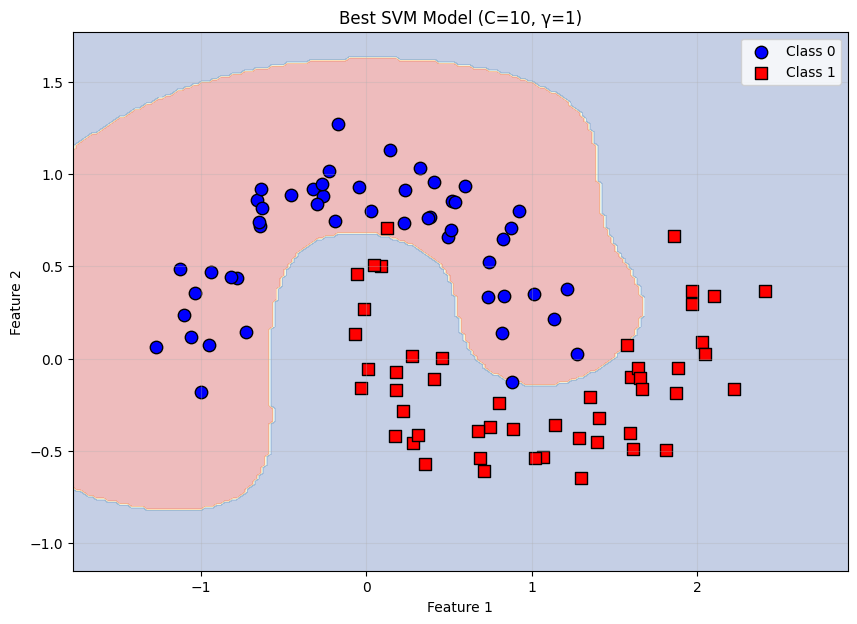


💡 Best practice: Always use cross-validation for hyperparameter tuning!


In [22]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Split data for proper evaluation
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, 
                                                      test_size=0.2, random_state=42)

# Define parameter grid
param_grid = {
    'svm_clf__C': [0.1, 1, 10, 100],
    'svm_clf__gamma': [0.1, 1, 10, 100],
}

# Create pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", random_state=42))
])

# Grid search with cross-validation
grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, 
                           scoring='accuracy', verbose=1, n_jobs=-1)

print("Performing grid search... (this may take a moment)")
grid_search.fit(X_train, y_train)

print("\nGrid Search Results:")
print("=" * 60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")

# Show top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.nlargest(5, 'mean_test_score')[
    ['param_svm_clf__C', 'param_svm_clf__gamma', 'mean_test_score', 'std_test_score']
]
print("\nTop 5 parameter combinations:")
print(top_results.to_string(index=False))

# Visualize the best model
best_model = grid_search.best_estimator_
plot_decision_boundary(best_model, X_moons, y_moons, 
                       f"Best SVM Model (C={grid_search.best_params_['svm_clf__C']}, "
                       f"γ={grid_search.best_params_['svm_clf__gamma']})")

print("\n💡 Best practice: Always use cross-validation for hyperparameter tuning!")

## Part 7: Key Takeaways and Summary

### 🎯 Core Concepts

1. **Large Margin Classification**: SVMs fit the widest possible street between classes
2. **Support Vectors**: The instances on the edge of the street that define the decision boundary
3. **Kernel Trick**: Enables computing in high-dimensional spaces without explicit transformation

### ⚙️ Important Hyperparameters

| Hyperparameter | Effect | Tuning Guide |
|---------------|--------|--------------|
| **C** | Regularization strength | Lower C = more regularization, wider margin |
| **gamma (γ)** | RBF kernel width | Higher γ = narrower influence, more complex boundary |
| **degree** | Polynomial degree | Higher degree = more complex, risk of overfitting |
| **epsilon (ε)** | Regression margin width | Larger ε = wider margin, more tolerance |

### 🚀 When to Use What

**LinearSVC:**
- ✅ Large datasets (100k+ instances)
- ✅ High-dimensional data
- ✅ Linear problems
- ⚡ Fastest training

**SVC with RBF kernel:**
- ✅ Small/medium datasets (< 10k instances)
- ✅ Nonlinear problems
- ✅ Complex decision boundaries
- 🐌 Slower training

**SGDClassifier:**
- ✅ Online learning
- ✅ Huge datasets (out-of-core)
- ✅ Incremental training
- ⚡ Fast but less accurate

### ⚠️ Critical Best Practices

1. **Always scale features** before training SVMs
2. **Try linear kernel first**, especially for large datasets
3. **Use grid search** with cross-validation for hyperparameter tuning
4. **Start with coarse grid**, then fine-tune around best values
5. **For LinearSVC**: Set `loss="hinge"` and `dual=False`

### 📊 Complexity Comparison

```
LinearSVC:     O(m × n)           → Scales well with large datasets
SGDClassifier: O(m × n)           → Scales well, supports online learning
SVC:           O(m² × n) to O(m³ × n) → Slow for large datasets
```

### 🎓 SVM Capabilities

- ✅ Binary classification (linear and nonlinear)
- ✅ Multiclass classification (one-vs-rest or one-vs-one)
- ✅ Regression (linear and nonlinear)
- ✅ Outlier detection
- ✅ Works well with small/medium datasets
- ⚠️ Does not output class probabilities (unlike Logistic Regression)

### 💡 Final Wisdom

> "SVMs are powerful tools for classification and regression. They work especially well on small to medium-sized datasets with complex patterns. The kernel trick is one of the most elegant concepts in machine learning, allowing SVMs to efficiently work in high or even infinite-dimensional spaces!"

---

## Congratulations! 🎉

You've completed this comprehensive SVM tutorial. You now understand:
- How SVMs work under the hood
- When and how to use different kernels
- How to tune hyperparameters effectively
- The trade-offs between different SVM implementations

**Next steps:**
1. Try the practice exercises from the README
2. Apply SVMs to your own datasets
3. Experiment with different kernels and hyperparameters
4. Compare SVM performance with other algorithms

Happy learning! 🚀